In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# -*- coding: utf-8 -*-
"""Bước 1: đọc bộ dữ liệu sinh viên và xem qua một lượt.

Chú thích trong tệp viết tiếng Việt có dấu, nhưng phần in ra màn hình cố ý
viết không dấu. Cửa sổ lệnh Windows thường không hiện được chữ có dấu.
"""

import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/HM&UD/Lab2/sinh_vien.csv")

print("Kich thuoc bang (so dong, so cot):", df.shape)
print()
print("Nam dong dau tien:")
print(df.head())
print()

# Cột qua_mon chỉ có hai giá trị, đếm số lần xuất hiện từng giá trị
print("So sinh vien theo ket qua:")
print(df["qua_mon"].value_counts())
print()

print("Ty le qua mon:", round(df["qua_mon"].mean(), 4))
print()

# So sánh số giờ ôn trung bình của hai nhóm
print("So gio on trung binh theo nhom:")
print(df.groupby("qua_mon")["gio_on"].mean().round(2))

Kich thuoc bang (so dong, so cot): (120, 3)

Nam dong dau tien:
   gio_on  diem_giua_ky  qua_mon
0     5.5           3.0        0
1    19.0           6.0        1
2    14.0           7.7        0
3    11.0           3.1        0
4    10.5           5.8        1

So sinh vien theo ket qua:
qua_mon
1    71
0    49
Name: count, dtype: int64

Ty le qua mon: 0.5917

So gio on trung binh theo nhom:
qua_mon
0     8.29
1    19.89
Name: gio_on, dtype: float64


In [7]:
# -*- coding: utf-8 -*-
"""Bước 2: làm quen hàm sigmoid bằng tay trước khi gọi thư viện."""

import numpy as np


def sigmoid(z):
    """Ép một số thực bất kỳ về khoảng từ 0 tới 1."""
    return 1 / (1 + np.exp(-z))


print("Bang gia tri cua ham sigmoid")
print(" z        sigmoid(z)")
for z in [-6, -4, -2, -1, 0, 1, 2, 4, 6]:
    print(f"{z:3d}        {sigmoid(z):.4f}")
print()

# Hai tính chất cần tự kiểm chứng
print("Kiem tra sigmoid(-z) = 1 - sigmoid(z):")
for z in [1.0, 2.5, 3.7]:
    trai = sigmoid(-z)
    phai = 1 - sigmoid(z)
    print(f" z = {z}:  {trai:.6f}  va  {phai:.6f}")
print()

# Thử với một mô hình giả định w = 0.4 và b = -5
w, b = 0.4, -5.0
print(f"Mo hinh gia dinh: w = {w}, b = {b}")
print(" So gio on     z = w*x + b    Xac suat qua mon")
for gio in [5, 10, 12.5, 15, 20, 25]:
    z = w * gio + b
    print(f"  {gio:5.1f}          {z:6.2f}            {sigmoid(z):.4f}")

Bang gia tri cua ham sigmoid
 z        sigmoid(z)
 -6        0.0025
 -4        0.0180
 -2        0.1192
 -1        0.2689
  0        0.5000
  1        0.7311
  2        0.8808
  4        0.9820
  6        0.9975

Kiem tra sigmoid(-z) = 1 - sigmoid(z):
 z = 1.0:  0.268941  va  0.268941
 z = 2.5:  0.075858  va  0.075858
 z = 3.7:  0.024127  va  0.024127

Mo hinh gia dinh: w = 0.4, b = -5.0
 So gio on     z = w*x + b    Xac suat qua mon
    5.0           -3.00            0.0474
   10.0           -1.00            0.2689
   12.5            0.00            0.5000
   15.0            1.00            0.7311
   20.0            3.00            0.9526
   25.0            5.00            0.9933


In [8]:
# -*- coding: utf-8 -*-
"""Bước 3: để scikit-learn tìm w và b từ dữ liệu thật."""

import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/HM&UD/Lab2/sinh_vien.csv")

# X phải là bảng hai chiều nên viết hai cặp ngoặc vuông.
# y là dãy một chiều nên chỉ một cặp.
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)

w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

print(f"He so goc  w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()

# Số giờ ôn mà mô hình phân vân đúng năm mươi năm mươi
print(f"So gio on ung voi xac suat 0.5: {-b / w:.2f} gio")
print()

can_moi = pd.DataFrame({"gio_on": [5.0, 10.0, 13.0, 20.0, 28.0]})
xac_suat = mo_hinh.predict_proba(can_moi)[:, 1]
nhan = mo_hinh.predict(can_moi)

print("Du doan cho nam ban moi:")
print(" So gio on    Xac suat qua    Nhan mo hinh dua ra")
for gio, p, n in zip(can_moi["gio_on"], xac_suat, nhan):
    print(f"  {gio:5.1f}           {p:.4f}               {n}")

He so goc  w = 0.392819
He so chan b = -5.064890

So gio on ung voi xac suat 0.5: 12.89 gio

Du doan cho nam ban moi:
 So gio on    Xac suat qua    Nhan mo hinh dua ra
    5.0           0.0431               0
   10.0           0.2429               0
   13.0           0.5104               1
   20.0           0.9422               1
   28.0           0.9974               1


In [9]:
# -*- coding: utf-8 -*-
"""Bước 4: chia dữ liệu rồi chấm điểm mô hình bằng bốn thước đo."""

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/HM&UD/Lab2/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

# stratify=y giữ đúng tỷ lệ qua và rớt ở cả hai phần sau khi chia
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

print("So sinh vien de hoc   :", len(X_train))
print("So sinh vien de kiem tra:", len(X_test))
print()

mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test)

# Thứ tự bốn ô do scikit-learn quy định là TN, FP, FN, TP
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("Ma tran nham lan")
print(f"  TN = {tn:2d}  doan rot, that su rot")
print(f"  FP = {fp:2d}  doan qua, that ra rot")
print(f"  FN = {fn:2d}  doan rot, that ra qua")
print(f"  TP = {tp:2d}  doan qua, that su qua")
print()

print(f"Accuracy  = {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision = {precision_score(y_test, y_pred):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred):.4f}")
print(f"F1        = {f1_score(y_test, y_pred):.4f}")
print()

# Tự tính lại bằng tay để đối chiếu với thư viện
print("Tu tinh lai bang cong thuc:")
n = len(y_test)
print(f"  Accuracy  = ({tp} + {tn}) / {n} = {(tp + tn) / n:.4f}")
print(f"  Precision = {tp} / ({tp} + {fp}) = {tp / (tp + fp):.4f}")
print(f"  Recall    = {tp} / ({tp} + {fn}) = {tp / (tp + fn):.4f}")

So sinh vien de hoc   : 90
So sinh vien de kiem tra: 30

Ma tran nham lan
  TN =  9  doan rot, that su rot
  FP =  3  doan qua, that ra rot
  FN =  1  doan rot, that ra qua
  TP = 17  doan qua, that su qua

Accuracy  = 0.8667
Precision = 0.8500
Recall    = 0.9444
F1        = 0.8947

Tu tinh lai bang cong thuc:
  Accuracy  = (17 + 9) / 30 = 0.8667
  Precision = 17 / (17 + 3) = 0.8500
  Recall    = 17 / (17 + 1) = 0.9444


In [10]:
# -*- coding: utf-8 -*-
"""Bước 5: tự áp ngưỡng và xem precision với recall đổi ra sao."""

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/HM&UD/Lab2/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

# predict_proba trả về hai cột, cột 0 cho Lớp 0 và cột 1 cho Lớp 1
p = mo_hinh.predict_proba(X_test)[:, 1]

print("Nguong   So ban bi doan la qua    Precision    Recall")
for nguong in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    y_pred = (p >= nguong).astype(int)
    pre = precision_score(y_test, y_pred, zero_division=1)
    rec = recall_score(y_test, y_pred, zero_division=0)
    print(
        f"{nguong:.1f}              {y_pred.sum():3d}             {pre:.4f}       {rec:.4f}"
    )
print()

print("Doc bang tren tu duoi len:")
print("  Nguong cang cao thi mo hinh cang kho tinh,")
print(
    "  precision tang nhung recall giam. Nguong thap thi nguoc lai."
)

Nguong   So ban bi doan la qua    Precision    Recall
0.2               24             0.7500       1.0000
0.3               20             0.8500       0.9444
0.4               20             0.8500       0.9444
0.5               20             0.8500       0.9444
0.6               16             1.0000       0.8889
0.7               15             1.0000       0.8333
0.8               13             1.0000       0.7222

Doc bang tren tu duoi len:
  Nguong cang cao thi mo hinh cang kho tinh,
  precision tang nhung recall giam. Nguong thap thi nguoc lai.


In [11]:
# -*- coding: utf-8 -*-
"""Bước 6: thêm điểm giữa kỳ làm biến thứ hai."""

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/HM&UD/Lab2/sinh_vien.csv")
y = df["qua_mon"]

# Chỉ đổi đúng một chỗ: danh sách cột đưa vào X
for ten, cot in [
    ("Mot bien", ["gio_on"]),
    ("Hai bien", ["gio_on", "diem_giua_ky"]),
]:
    X = df[cot]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=17, stratify=y
    )
    mo_hinh = LogisticRegression().fit(X_train, y_train)
    do_chinh_xac = accuracy_score(y_test, mo_hinh.predict(X_test))
    print(f"{ten}: accuracy tren tap kiem tra = {do_chinh_xac:.4f}")
print()

# Xem kỹ hệ số của mô hình hai biến
X = df[["gio_on", "diem_giua_ky"]]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X.columns, mo_hinh.coef_[0]):
    print(f"  {ten_cot:14s} {he_so:+.4f}")
print(f"  {'he so chan':14s} {mo_hinh.intercept_[0]:+.4f}")
print()
print("Ca hai he so deu duong, nghia la on nhieu hon va")
print("diem giua ky cao hon deu lam tang xac suat qua mon.")

Mot bien: accuracy tren tap kiem tra = 0.8667
Hai bien: accuracy tren tap kiem tra = 0.9000

He so cua tung bien:
  gio_on         +0.3035
  diem_giua_ky   +0.5885
  he so chan     -6.9811

Ca hai he so deu duong, nghia la on nhieu hon va
diem giua ky cao hon deu lam tang xac suat qua mon.


8 bài tập

In [12]:
# -*- coding: utf-8 -*-
import pandas as pd

# Đọc dữ liệu
df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/HM&UD/Lab2/sinh_vien.csv")

# Lọc nhóm có điểm giữa kỳ từ 7 trở lên và nhóm còn lại
nhom_7_tro_len = df[df["diem_giua_ky"] >= 7]
nhom_con_lai = df[df["diem_giua_ky"] < 7]

# Tính toán các giá trị
so_luong_7_tro_len = len(nhom_7_tro_len)
ty_le_pass_7_tro_len = nhom_7_tro_len["qua_mon"].mean()
ty_le_pass_con_lai = nhom_con_lai["qua_mon"].mean()

print(f"So ban co diem giua ky tu 7 tro len: {so_luong_7_tro_len}")
print(f"Ty le qua mon cua nhom diem giua ky >= 7: {ty_le_pass_7_tro_len:.4f}")
print(f"Ty le qua mon cua nhom con lai (< 7): {ty_le_pass_con_lai:.4f}")

# Nhận xét
print("\nNhan xet:")
print("Diem giua ky phan biet rat tot hai nhom: sinh vien co diem giua ky >= 7")
print("co ty le qua mon cao hon ro ret so voi nhom co diem giua ky < 7.")

So ban co diem giua ky tu 7 tro len: 31
Ty le qua mon cua nhom diem giua ky >= 7: 0.9032
Ty le qua mon cua nhom con lai (< 7): 0.4831

Nhan xet:
Diem giua ky phan biet rat tot hai nhom: sinh vien co diem giua ky >= 7
co ty le qua mon cao hon ro ret so voi nhom co diem giua ky < 7.


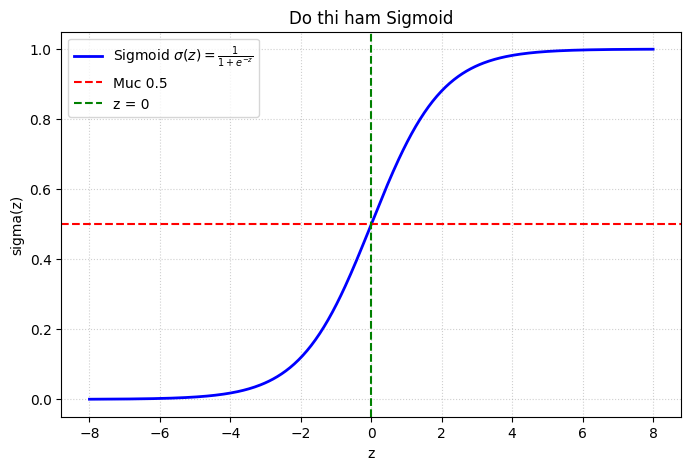

Da luu do thi thanh cong vao baitap02/sigmoid.png


In [13]:
# câu 2-*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np
import os

# Tạo dải giá trị z từ -8 đến 8
z = np.linspace(-8, 8, 400)
# Công thức hàm sigmoid
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid, label=r"Sigmoid $\sigma(z) = \frac{1}{1 + e^{-z}}$", color="blue", linewidth=2)

# Đường ngang tại y = 0.5 và đường dọc tại z = 0
plt.axhline(y=0.5, color="red", linestyle="--", label="Muc 0.5")
plt.axvline(x=0, color="green", linestyle="--", label="z = 0")

plt.title("Do thi ham Sigmoid")
plt.xlabel("z")
plt.ylabel("sigma(z)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

# Tạo thư mục 'baitap02' nếu nó chưa tồn tại
os.makedirs("baitap02", exist_ok=True)

# Lưu đồ thị thành tệp sigmoid.png
plt.savefig("baitap02/sigmoid.png", bbox_inches="tight")
plt.show()
print("Da luu do thi thanh cong vao baitap02/sigmoid.png")

In [14]:
#câu 3 -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Khớp mô hình 1 biến (gio_on)
df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/HM&UD/Lab2/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression().fit(X, y)

w1 = mo_hinh.coef_[0][0]
b = mo_hinh.intercept_[0]

def du_doan(gio):
    # Tính z = w1 * x + b
    z = w1 * gio + b
    # Tính xác suất qua môn p = sigmoid(z)
    p = 1 / (1 + np.exp(-z))
    # Nhãn theo ngưỡng 0.5
    nhan = 1 if p >= 0.5 else 0
    return z, p, nhan

cac_muc_gio = [3, 8, 12.89, 18, 26]

print(f"{'Gio on':<10}{'Gia tri z':<15}{'Xac suat (p)':<18}{'Nhan (nguong 0.5)':<10}")
print("-" * 55)
for gio in cac_muc_gio:
    z, p, nhan = du_doan(gio)
    print(f"{gio:<10.2f}{z:<15.4f}{p:<18.4f}{nhan:<10}")

print("\nGiai thich cho muc 12.89 gio:")
print(f"Vi tai gio_on = 12.89, gia tri z = {w1 * 12.89 + b:.4f} rat gan voi 0.")
print("Ma ham sigmoid(0) = 1 / (1 + e^0) = 1 / 2 = 0.5, do do xac suat p ra gan dung 0.5.")

Gio on    Gia tri z      Xac suat (p)      Nhan (nguong 0.5)
-------------------------------------------------------
3.00      -3.8864        0.0201            0         
8.00      -1.9223        0.1276            0         
12.89     -0.0015        0.4996            0         
18.00     2.0059         0.8814            1         
26.00     5.1484         0.9942            1         

Giai thich cho muc 12.89 gio:
Vi tai gio_on = 12.89, gia tri z = -0.0015 rat gan voi 0.
Ma ham sigmoid(0) = 1 / (1 + e^0) = 1 / 2 = 0.5, do do xac suat p ra gan dung 0.5.


In [15]:
#câu 4 -*- coding: utf-8 -*-
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/HM&UD/Lab2/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

# Lấy 4 giá trị từ confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
n = len(y_test)

# Tự tính 4 thước đo bằng công thức toán học
accuracy = (tp + tn) / n
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print("Ket qua tu tinh bang cong thuc dai so:")
print(f"  Accuracy  = ({tp} + {tn}) / {n} = {accuracy:.4f}")
print(f"  Precision = {tp} / ({tp} + {fp}) = {precision:.4f}")
print(f"  Recall    = {tp} / ({tp} + {fn}) = {recall:.4f}")
print(f"  F1-score  = 2 * ({precision:.4f} * {recall:.4f}) / ({precision:.4f} + {recall:.4f}) = {f1:.4f}")

print("\nSo sanh voi ket qua trong tai lieu:")
print("  Doi chieu voi muc 5.2: Accuracy=0.8667, Precision=0.8500, Recall=0.9444, F1=0.8947.")
print("  -> Ket qua tu tinh hoan toan khop 100% voi thu vien scikit-learn.")

Ket qua tu tinh bang cong thuc dai so:
  Accuracy  = (17 + 9) / 30 = 0.8667
  Precision = 17 / (17 + 3) = 0.8500
  Recall    = 17 / (17 + 1) = 0.9444
  F1-score  = 2 * (0.8500 * 0.9444) / (0.8500 + 0.9444) = 0.8947

So sanh voi ket qua trong tai lieu:
  Doi chieu voi muc 5.2: Accuracy=0.8667, Precision=0.8500, Recall=0.9444, F1=0.8947.
  -> Ket qua tu tinh hoan toan khop 100% voi thu vien scikit-learn.


In [16]:
#câu 5 -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/HM&UD/Lab2/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
p = mo_hinh.predict_proba(X_test)[:, 1]

nguong_list = np.arange(0.05, 1.0, 0.05)
best_f1 = -1
best_nguong = None

print(f"{'Nguong':<12}{'F1-score':<12}")
print("-" * 24)

for nguong in nguong_list:
    y_pred = (p >= nguong).astype(int)
    score = f1_score(y_test, y_pred, zero_division=0)
    print(f"{nguong:<12.2f}{score:<12.4f}")
    if score > best_f1:
        best_f1 = score
        best_nguong = nguong

print("-" * 24)
print(f"Nguong cho F1 cao nhat la: {best_nguong:.2f} (F1 = {best_f1:.4f})")

print("\nNhan xet:")
if round(best_nguong, 2) == 0.5:
    print("Nguong tot nhat theo F1 dung bang 0.5.")
else:
    print(f"Nguong tot nhat theo F1 la {best_nguong:.2f}, KHONG bang 0.5. Nguyen nhan do tap du lieu bi lech lop hoac phan bo xac suat cua mo hinh dat diem can bang F1 toi uu tai nguong nay.")

Nguong      F1-score    
------------------------
0.05        0.7826      
0.10        0.8182      
0.15        0.8182      
0.20        0.8571      
0.25        0.9000      
0.30        0.8947      
0.35        0.8947      
0.40        0.8947      
0.45        0.8947      
0.50        0.8947      
0.55        0.8889      
0.60        0.9412      
0.65        0.9412      
0.70        0.9091      
0.75        0.8750      
0.80        0.8387      
0.85        0.8000      
0.90        0.5600      
0.95        0.4348      
------------------------
Nguong cho F1 cao nhat la: 0.60 (F1 = 0.9412)

Nhan xet:
Nguong tot nhat theo F1 la 0.60, KHONG bang 0.5. Nguyen nhan do tap du lieu bi lech lop hoac phan bo xac suat cua mo hinh dat diem can bang F1 toi uu tai nguong nay.


In [17]:
# câu 6-*- coding: utf-8 -*-
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/HM&UD/Lab2/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

# Chấm điểm khi coi Lớp 0 (Rớt môn) là lớp dương (pos_label=0)
pre_0 = precision_score(y_test, y_pred, pos_label=0)
rec_0 = recall_score(y_test, y_pred, pos_label=0)

# Chấm điểm khi coi Lớp 1 (Qua môn) là lớp dương (pos_label=1)
pre_1 = precision_score(y_test, y_pred, pos_label=1)
rec_1 = recall_score(y_test, y_pred, pos_label=1)

print("Ket qua cham diem theo lop dương:")
print(f"  Lop 1 (Qua mon) : Precision = {pre_1:.4f}, Recall = {rec_1:.4f}")
print(f"  Lop 0 (Rot mon) : Precision = {pre_0:.4f}, Recall = {rec_0:.4f}")

print("\nGiải thích bằng lời vì sao hai bộ số khác nhau:")
print("1. Công thức Precision và Recall phụ thuộc trực tiếp vào việc xác định đối tượng là 'lớp dương' (Positive):")
print("   - Với Lop 1: Precision = TP / (TP + FP) = 17 / (17 + 3) = 0.8500")
print("                Recall    = TP / (TP + FN) = 17 / (17 + 1) = 0.9444")
print("   - Với Lop 0: Precision = TN / (TN + FN) = 9 / (9 + 1)   = 0.9000")
print("                Recall    = TN / (TN + FP) = 9 / (9 + 3)   = 0.7500")
print("2. Khi hoán đổi lớp dương từ 1 sang 0, vai trò của TP và TN bị đảo ngược, đồng thời FP và FN cũng tráo đổi vai trò cho nhau.")
print("3. Do số lượng mẫu thực tế giữa lớp Qua môn (18 sinh viên) và Rớt môn (12 sinh viên) trong tập test là không bằng nhau (mất cân bằng nhãn), dẫn đến tỉ lệ đoán đúng/sót trên từng lớp là hoàn toàn khác nhau.")

Ket qua cham diem theo lop dương:
  Lop 1 (Qua mon) : Precision = 0.8500, Recall = 0.9444
  Lop 0 (Rot mon) : Precision = 0.9000, Recall = 0.7500

Giải thích bằng lời vì sao hai bộ số khác nhau:
1. Công thức Precision và Recall phụ thuộc trực tiếp vào việc xác định đối tượng là 'lớp dương' (Positive):
   - Với Lop 1: Precision = TP / (TP + FP) = 17 / (17 + 3) = 0.8500
                Recall    = TP / (TP + FN) = 17 / (17 + 1) = 0.9444
   - Với Lop 0: Precision = TN / (TN + FN) = 9 / (9 + 1)   = 0.9000
                Recall    = TN / (TN + FP) = 9 / (9 + 3)   = 0.7500
2. Khi hoán đổi lớp dương từ 1 sang 0, vai trò của TP và TN bị đảo ngược, đồng thời FP và FN cũng tráo đổi vai trò cho nhau.
3. Do số lượng mẫu thực tế giữa lớp Qua môn (18 sinh viên) và Rớt môn (12 sinh viên) trong tập test là không bằng nhau (mất cân bằng nhãn), dẫn đến tỉ lệ đoán đúng/sót trên từng lớp là hoàn toàn khác nhau.
